# 01 — Análisis exploratorio de datos

**Proyecto 1: Competencia de modelación** · CC3092 Deep Learning y sistemas inteligentes

El objetivo de este notebook es entender el dataset **antes** de entrenar cualquier
modelo, y dejar justificada cada decisión de preprocesamiento que después aplico
en `src/preprocessing.py`.

Corresponde a la sección **2.1** del trabajo escrito.

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from config import FIGURES, TARGET, TRAIN_CSV
from utils import load_csv, set_seed

set_seed()
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 120)

df = load_csv(TRAIN_CSV)
print(f"Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")

Dimensiones: 1168 filas x 81 columnas


## 1. Estructura del dataset

Es el dataset **Ames Housing**: cada fila es la venta de una casa y la variable
objetivo es `SalePrice` (precio de venta en USD). Es un problema de **regresión**,
lo que fija la métrica del proyecto: RMSE.

In [2]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,255,20,RL,70.0,8400,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,145000
1,1067,60,RL,59.0,7837,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2009,WD,Normal,178000
2,639,30,RL,67.0,8777,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,5,2008,WD,Normal,85000
3,800,50,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2007,WD,Normal,175000
4,381,50,RL,50.0,5000,Pave,Pave,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,127000


### Tipos de variables

El dataset mezcla tres naturalezas distintas, y cada una necesita un tratamiento
diferente en el preprocesamiento:

- **Numéricas continuas** — superficies, precios, años.
- **Categóricas nominales** — vecindario, tipo de techo: sin orden natural.
- **Categóricas ordinales** — calidades `Po < Fa < TA < Gd < Ex`: sí tienen orden.

In [3]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop(["Id", TARGET])
cat_cols = df.select_dtypes(exclude=[np.number]).columns

print(f"Numéricas (sin Id/target): {len(num_cols)}")
print(f"Categóricas: {len(cat_cols)}")

resumen = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unicos": df.nunique(dropna=True),
    "n_nulos": df.isna().sum(),
    "pct_nulos": (df.isna().mean() * 100).round(2),
})
resumen.sort_values("pct_nulos", ascending=False).head(25)

Numéricas (sin Id/target): 36
Categóricas: 43


,dtype,n_unicos,n_nulos,pct_nulos
PoolQC,str,3,1162,99.49
MiscFeature,str,4,1122,96.06
Alley,str,2,1094,93.66
Fence,str,4,935,80.05
MasVnrType,str,3,683,58.48
FireplaceQu,str,5,547,46.83
LotFrontage,float64,107,217,18.58
GarageYrBlt,float64,94,64,5.48
GarageCond,str,5,64,5.48
GarageType,str,6,64,5.48


## 2. La variable objetivo: `SalePrice`

In [4]:
y = df[TARGET]
print(f"media    {y.mean():>12,.0f}")
print(f"mediana  {y.median():>12,.0f}")
print(f"std      {y.std():>12,.0f}")
print(f"min      {y.min():>12,.0f}")
print(f"max      {y.max():>12,.0f}")
print(f"skew     {y.skew():>12.3f}")
print(f"kurtosis {y.kurtosis():>12.3f}")

media         181,442
mediana       165,000
std            77,264
min            34,900
max           745,000
skew            1.743
kurtosis        5.475


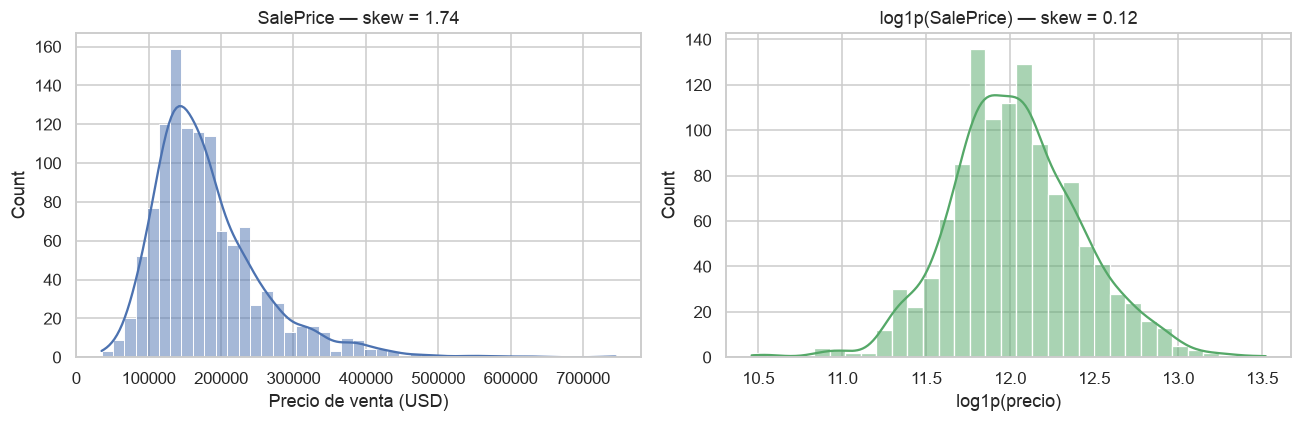

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y, kde=True, ax=axes[0], color="#4C72B0")
axes[0].set_title(f"SalePrice — skew = {y.skew():.2f}")
axes[0].set_xlabel("Precio de venta (USD)")

sns.histplot(np.log1p(y), kde=True, ax=axes[1], color="#55A868")
axes[1].set_title(f"log1p(SalePrice) — skew = {np.log1p(y).skew():.2f}")
axes[1].set_xlabel("log1p(precio)")
plt.tight_layout()
plt.show()

**Decisión 1 — le aplico `log1p` al target.**

La distribución cruda tiene una cola derecha marcada (skew ≈ 1.74): unas pocas
casas de más de medio millón arrastran la media muy por encima de la mediana.
Con `log1p` el skew baja a ~0.12, casi simétrico.

Esto importa para el entrenamiento: con el target crudo, el gradiente queda
dominado por el error absoluto de las casas caras, y la red gasta su capacidad
ajustando un puñado de casos extremos en lugar del grueso de la distribución.
Predigo en escala logarítmica y lo devuelvo con `expm1` **antes** de medir el
RMSE, porque la métrica de la competencia está en dólares.

## 3. Valores nulos

El punto clave: en este dataset **la mayoría de los nulos no son datos faltantes**,
son ausencia del elemento. `PoolQC` nulo no significa "no sabemos la calidad de la
piscina", significa que la casa no tiene piscina. Imputarlos con la moda destruiría
esa información.

Columnas con nulos: 19


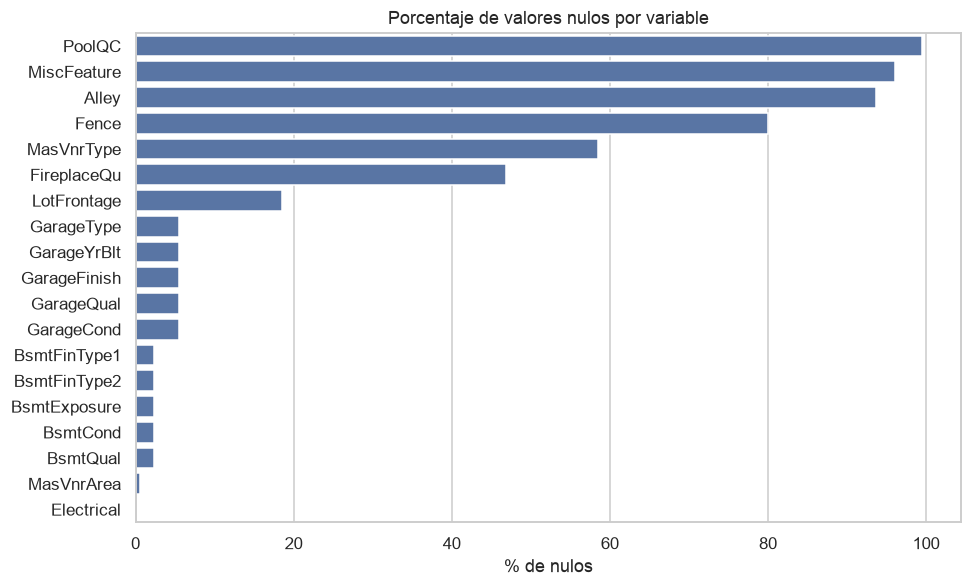

,dtype,n_unicos,n_nulos,pct_nulos
PoolQC,str,3,1162,99.49
MiscFeature,str,4,1122,96.06
Alley,str,2,1094,93.66
Fence,str,4,935,80.05
MasVnrType,str,3,683,58.48
FireplaceQu,str,5,547,46.83
LotFrontage,float64,107,217,18.58
GarageType,str,6,64,5.48
GarageYrBlt,float64,94,64,5.48
GarageFinish,str,3,64,5.48


In [6]:
nulos = resumen[resumen.n_nulos > 0].sort_values("pct_nulos", ascending=False)
print(f"Columnas con nulos: {len(nulos)}")

fig, ax = plt.subplots(figsize=(9, 5.5))
sns.barplot(x=nulos.pct_nulos, y=nulos.index, color="#4C72B0", ax=ax)
ax.set_title("Porcentaje de valores nulos por variable")
ax.set_xlabel("% de nulos")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

nulos

**Decisión 2 — imputo según lo que significa el nulo**, no según su frecuencia:

| Grupo | Variables | Imputación | Razón |
|---|---|---|---|
| Ausencia categórica | `PoolQC`, `Alley`, `Fence`, `FireplaceQu`, `Garage*`, `Bsmt*`, `MiscFeature`, `MasVnrType` | literal `"None"` | El nulo es una categoría legítima: "no tiene" |
| Ausencia numérica | `MasVnrArea`, `BsmtFinSF*`, `GarageArea`, `GarageCars` | `0` | Sin el elemento, la superficie es cero |
| `GarageYrBlt` | — | `YearBuilt` | Un año 0 rompería la escala; el garaje suele ser del año de la casa |
| Faltante real | `LotFrontage` (18.6%) | mediana **del vecindario** | El frente del lote lo determina la traza del vecindario |
| Faltante real | `Electrical` (1 caso) | moda | Un solo registro, sin impacto |

`LotFrontage` merece atención aparte: es el único nulo masivo que sí es un dato
faltante. Veamos si la mediana por vecindario tiene sentido.

Mediana global: 70.0
Rango de medianas por vecindario: 21 – 92


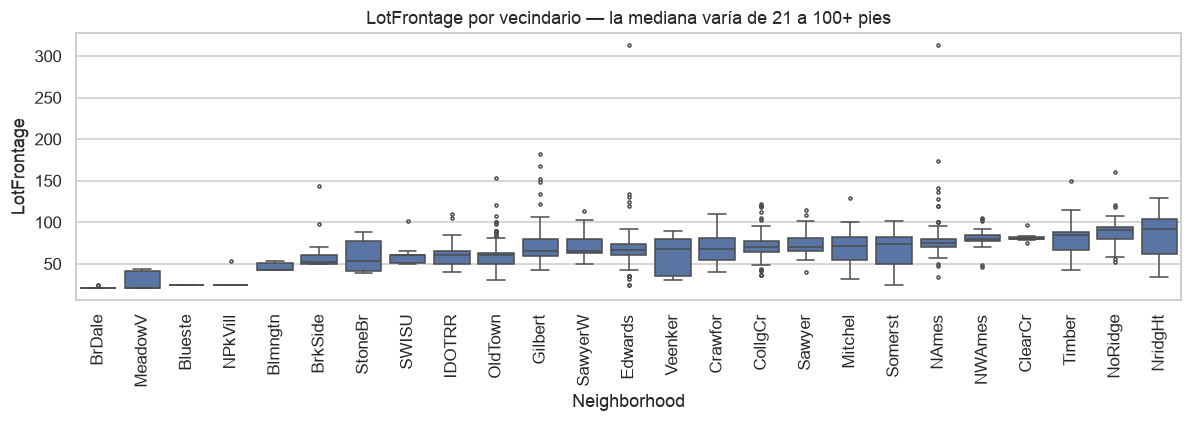

In [7]:
lf = df.groupby("Neighborhood")["LotFrontage"].agg(["median", "std", "count"])
lf = lf.sort_values("median")
print(f"Mediana global: {df.LotFrontage.median():.1f}")
print(f"Rango de medianas por vecindario: {lf['median'].min():.0f} – {lf['median'].max():.0f}")

fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="Neighborhood", y="LotFrontage",
            order=lf.index, ax=ax, fliersize=2)
ax.tick_params(axis="x", rotation=90)
ax.set_title("LotFrontage por vecindario — la mediana varía de 21 a 100+ pies")
plt.tight_layout()
plt.show()

La mediana por vecindario va de ~21 a ~100 pies. Usar una sola mediana global para
todo el dataset introduciría un error sistemático en los vecindarios de los extremos,
así que imputo por grupo.

## 4. Correlaciones con el precio

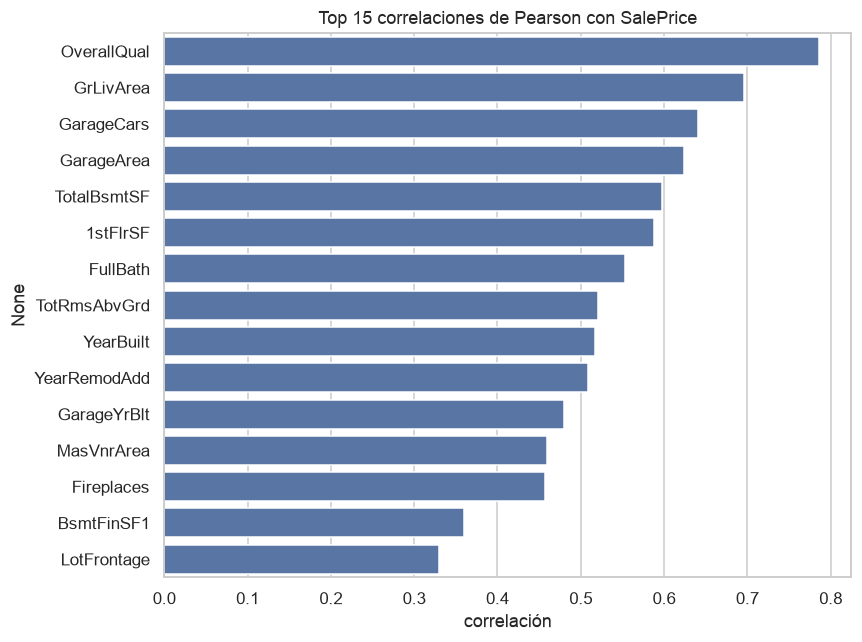

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,GarageYrBlt,MasVnrArea,Fireplaces,BsmtFinSF1,LotFrontage
corr,0.786,0.696,0.641,0.624,0.598,0.588,0.553,0.52,0.517,0.509,0.48,0.459,0.458,0.359,0.33


In [8]:
corr = df[num_cols.tolist() + [TARGET]].corr(numeric_only=True)[TARGET]
corr = corr.drop(TARGET).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
top15 = corr.head(15)
sns.barplot(x=top15.values, y=top15.index, color="#4C72B0", ax=ax)
ax.set_title("Top 15 correlaciones de Pearson con SalePrice")
ax.set_xlabel("correlación")
plt.tight_layout()
plt.show()

pd.DataFrame({"corr": corr.round(3)}).head(15).T

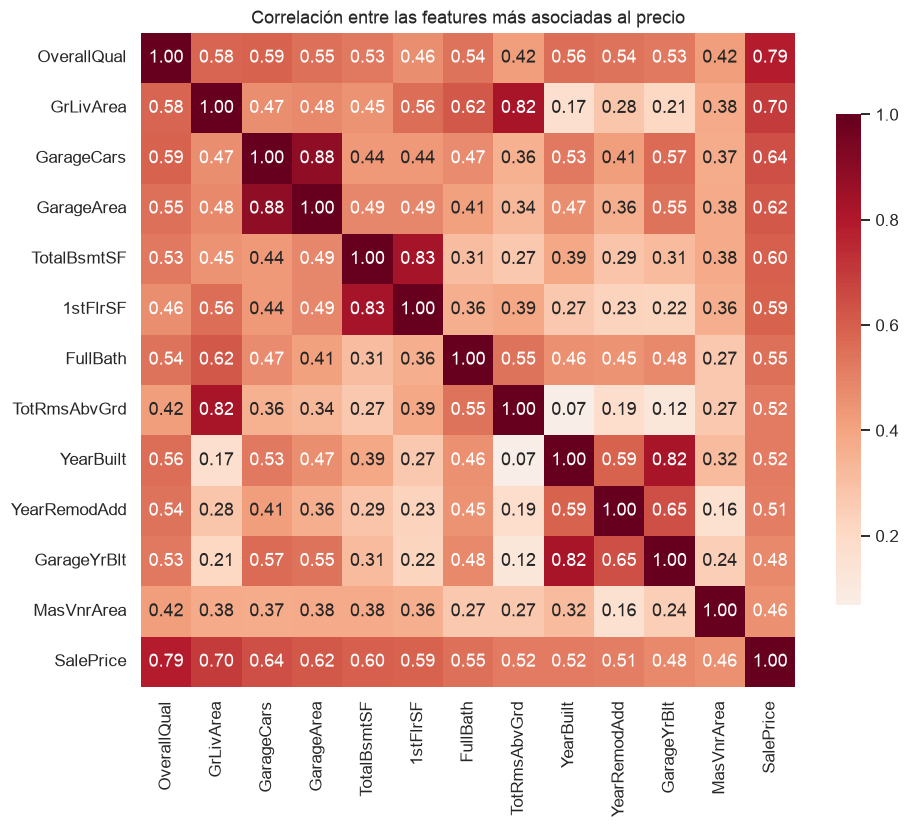

In [9]:
top = corr.abs().sort_values(ascending=False).head(12).index.tolist()
fig, ax = plt.subplots(figsize=(9, 7.5))
sns.heatmap(df[top + [TARGET]].corr(numeric_only=True), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, square=True, cbar_kws={"shrink": 0.75}, ax=ax)
ax.set_title("Correlación entre las features más asociadas al precio")
plt.tight_layout()
plt.show()

Veo bloques de **multicolinealidad** fuertes:

- `GarageCars` ↔ `GarageArea` (r ≈ 0.88) — miden lo mismo en unidades distintas.
- `TotalBsmtSF` ↔ `1stFlrSF` (r ≈ 0.82) — el sótano ocupa la huella del primer nivel.
- `GrLivArea` ↔ `TotRmsAbvGrd` (r ≈ 0.83) — más área, más cuartos.

**Decisión 3 — no elimino las colineales.** En una regresión lineal la
multicolinealidad inestabiliza los coeficientes, pero un MLP con weight decay
reparte el peso entre variables redundantes sin degradarse. Si las quito pierdo información (`GarageCars` y `GarageArea` no son lo mismo) a
cambio de nada.

## 5. Relación de cada feature con el target

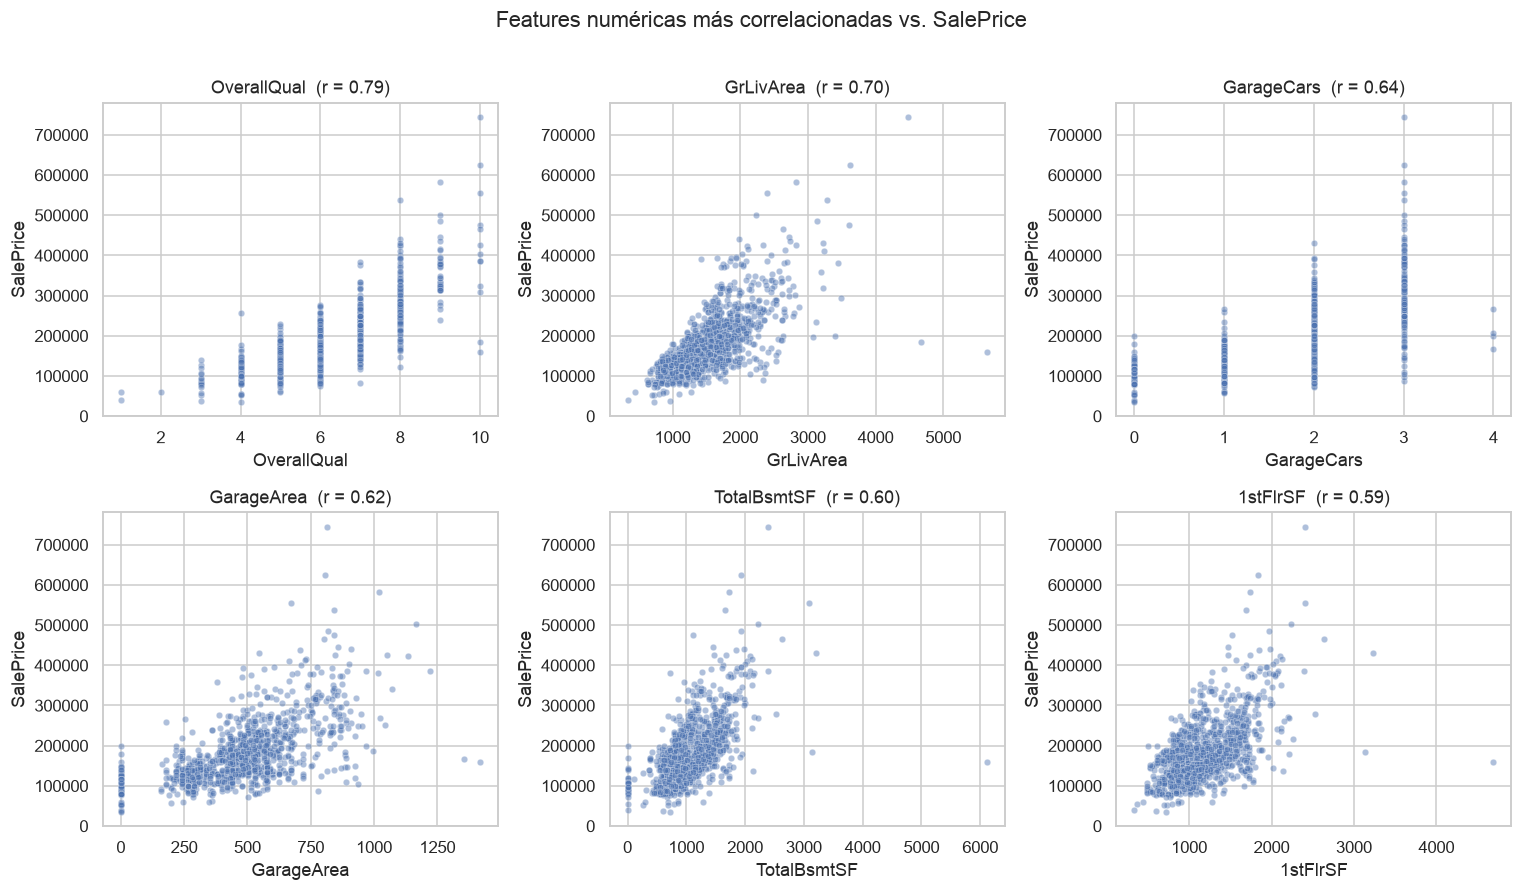

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), corr.head(6).index):
    sns.scatterplot(x=df[col], y=y, alpha=0.45, s=18, ax=ax, color="#4C72B0")
    ax.set_title(f"{col}  (r = {corr[col]:.2f})")
    ax.set_ylabel("SalePrice")
plt.suptitle("Features numéricas más correlacionadas vs. SalePrice", y=1.01)
plt.tight_layout()
plt.show()

`OverallQual` y `GrLivArea` muestran una relación claramente **no lineal**: el
precio se acelera en los valores altos. La curvatura (más marcada en calidad 9–10)
es exactamente el tipo de estructura que un MLP puede capturar y una regresión
lineal no — es la justificación de usar la red para este problema.

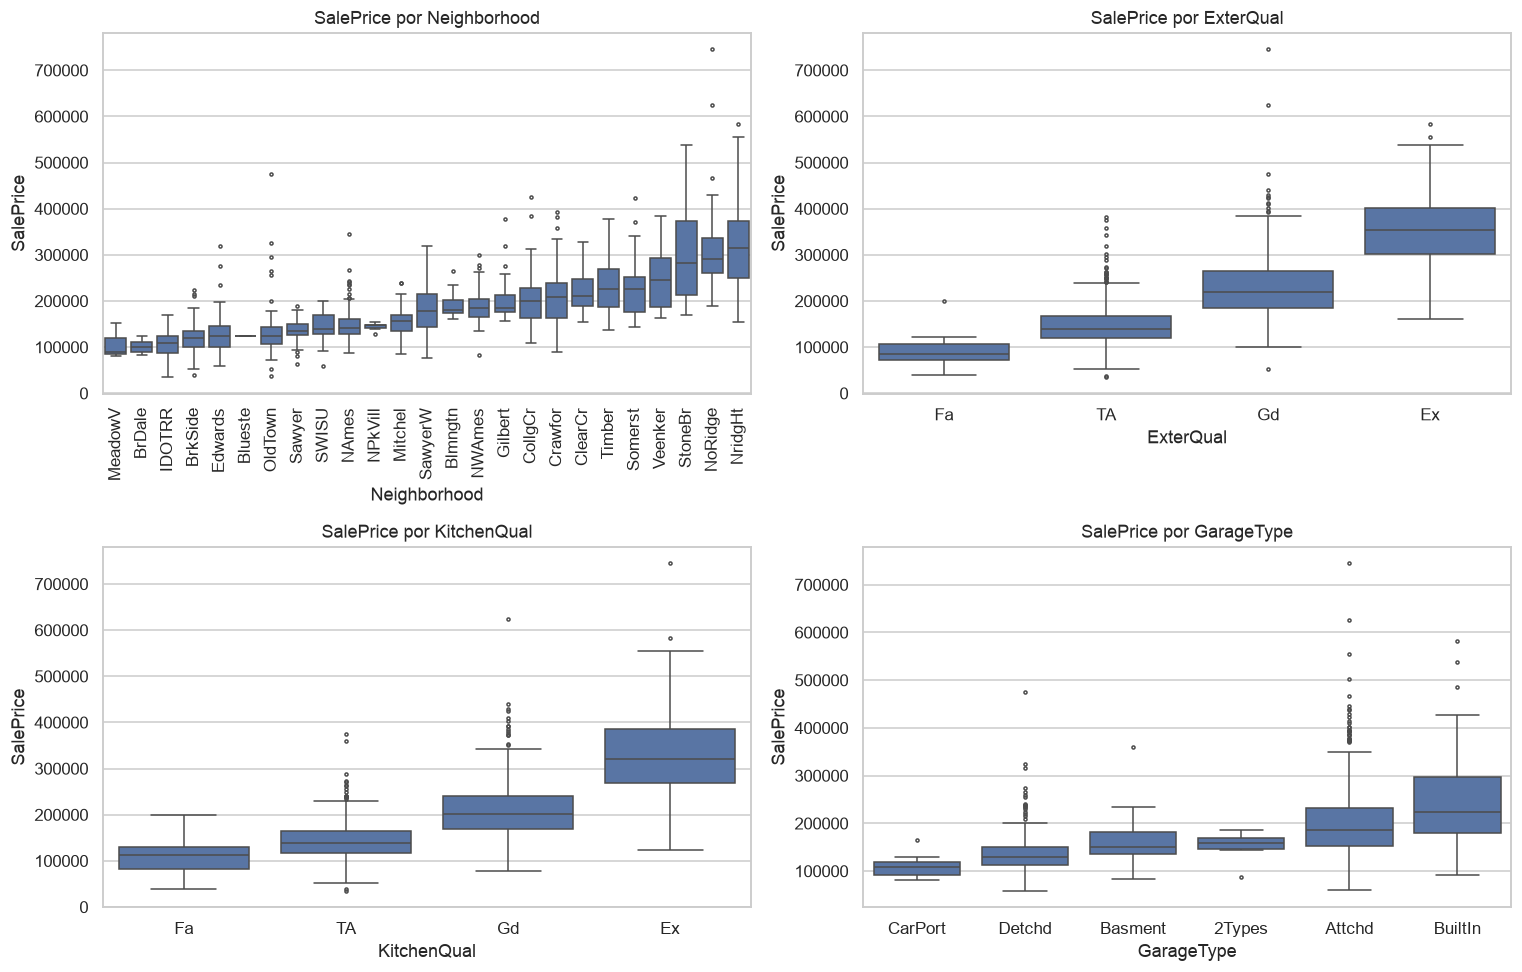

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col in zip(axes.ravel(), ["Neighborhood", "ExterQual", "KitchenQual", "GarageType"]):
    order = df.groupby(col, observed=True)[TARGET].median().sort_values().index
    sns.boxplot(data=df, x=col, y=TARGET, order=order, ax=ax, fliersize=2)
    ax.set_title(f"SalePrice por {col}")
    ax.tick_params(axis="x", rotation=90 if col == "Neighborhood" else 0)
plt.tight_layout()
plt.show()

Dos lecturas importantes:

1. **`Neighborhood` separa muy bien el precio** (de ~100k a ~300k de mediana), pero
   no tiene orden natural → codificación **one-hot**.
2. **Las calidades sí tienen orden monótono** con el precio (`Ex > Gd > TA > Fa > Po`)
   → codificación **ordinal** a enteros.

**Decisión 4 — uso codificación mixta.** Las ordinales (`ExterQual`, `KitchenQual`,
`BsmtQual`, `HeatingQC`, `GarageFinish`, `Functional`, …) las mapeo a enteros que
respetan el orden, con 1 columna en vez de *k*. Las nominales van a one-hot.
Con 1168 filas, gastar 5 columnas en algo que cabe en 1 me encarece el modelo sin
darle información nueva.

## 6. Outliers

In [12]:
q1, q3 = df[num_cols].quantile(0.25), df[num_cols].quantile(0.75)
iqr = q3 - q1
n_out = ((df[num_cols] < q1 - 1.5 * iqr) | (df[num_cols] > q3 + 1.5 * iqr)).sum()
n_out.sort_values(ascending=False).head(12)

EnclosedPorch    160
BsmtFinSF2       131
OverallCond       99
ScreenPorch       97
MSSubClass        84
MasVnrArea        77
LotFrontage       68
BsmtHalfBath      66
OpenPorchSF       60
KitchenAbvGr      56
LotArea           54
TotalBsmtSF       47
dtype: int64

El criterio IQR me marca cientos de "outliers", pero casi todos son legítimos: una
casa con piscina es rara, no está mal capturada. Si los descarto por regla
automática pierdo variabilidad real del mercado.

El caso que sí importa es el documentado del dataset de Ames: casas enormes vendidas
muy por debajo de su valor.

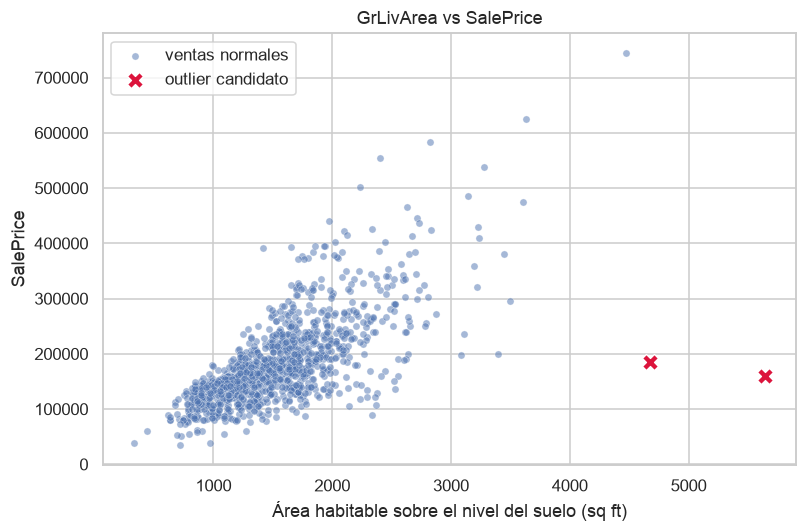

,Id,GrLivArea,OverallQual,SaleCondition,SalePrice
365,524,4676,10,Partial,184750
495,1299,5642,10,Partial,160000


In [13]:
out = df[(df.GrLivArea > 4000) & (df[TARGET] < 300000)]

fig, ax = plt.subplots(figsize=(7.5, 5))
sns.scatterplot(x=df.GrLivArea, y=y, alpha=0.5, s=22, ax=ax, label="ventas normales")
sns.scatterplot(x=out.GrLivArea, y=out[TARGET], color="crimson", s=110,
                marker="X", ax=ax, label="outlier candidato")
ax.set_title("GrLivArea vs SalePrice")
ax.set_xlabel("Área habitable sobre el nivel del suelo (sq ft)")
plt.tight_layout()
plt.show()

out[["Id", "GrLivArea", "OverallQual", "SaleCondition", TARGET]]

Los dos casos tienen `SaleCondition = Partial` y `OverallQual = 10`: son casas de
máxima calidad vendidas **sin terminar**, así que su precio no refleja el inmueble
completo. No son errores de captura, pero sí una relación distinta a la que el
modelo debe aprender.

**Decisión 5 — quito esos 2 casos solo del entrenamiento.** Nunca de validación ni
del holdout: si saco los casos difíciles también de la evaluación, inflo mi propia
métrica y me quedo con una idea falsa de cómo va el modelo. El impacto lo mido
como una iteración más (`it16`) en el notebook 02.

## 7. Ingeniería de features

El EDA me sugiere combinaciones que el MLP tendría que reconstruir solo. Dárselas
hechas acelera la convergencia, que con 1168 filas se agradece.

In [14]:
from preprocessing import add_engineered_features

X_fe = add_engineered_features(df.drop(columns=["Id", TARGET]))
nuevas = [c for c in X_fe.columns if c not in df.columns]
print(f"Features derivadas: {len(nuevas)}")
print(nuevas)

Features derivadas: 15
['TotalSF', 'TotalBath', 'TotalPorchSF', 'HouseAge', 'RemodAge', 'IsRemodeled', 'IsNew', 'HasPool', 'HasGarage', 'HasBsmt', 'HasFireplace', 'Has2ndFloor', 'QualxSF', 'QualxGrLiv', 'OverallScore']


In [15]:
X_fe[TARGET] = y
corr_new = X_fe[nuevas + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET)
comparacion = pd.DataFrame({"corr_con_SalePrice": corr_new.round(3)})
comparacion = comparacion.sort_values("corr_con_SalePrice", ascending=False)
comparacion

,corr_con_SalePrice
QualxSF,0.837
QualxGrLiv,0.817
TotalSF,0.766
TotalBath,0.621
OverallScore,0.555
HasFireplace,0.471
TotalPorchSF,0.389
HasGarage,0.248
IsNew,0.213
HasBsmt,0.156


`TotalSF` (sótano + primer + segundo nivel) y las interacciones `QualxSF` alcanzan
correlaciones **superiores a la de cualquier variable original**, incluida
`OverallQual` (0.786). Confirma que la superficie total y la interacción
calidad × área son los ejes reales del precio.

**Decisión 6 — agrego 15 features derivadas**: superficies totales, edad de la casa
al momento de la venta, indicadores de presencia (`HasPool`, `HasGarage`, …) e
interacciones calidad × área. Todas son transformaciones deterministas de columnas
existentes, así que no filtran información del target ni dependen del split.

## 8. Resumen de decisiones de preprocesamiento

Todas implementadas en `src/preprocessing.py`, ajustadas **solo** con datos de
entrenamiento y reaplicadas idénticas al dataset de prueba:

1. **Target** → `log1p(SalePrice)`; lo devuelvo con `expm1` antes de medir RMSE.
2. **Nulos** → imputación por significado (`"None"` / `0` / mediana por vecindario).
3. **Ordinales** → enteros que preservan el orden (`Po`=1 … `Ex`=5).
4. **Nominales** → one-hot con categorías fijadas en entrenamiento; un valor no visto
   en el test no crea columna nueva (queda en cero).
5. **Sesgo** → `log1p` en las numéricas con `|skew| > 0.75`.
6. **Escala** → estandarización z-score con la media y desviación del train.
7. **Outliers** → quito 2 ventas parciales, solo del split de entrenamiento.
8. **Features derivadas** → 15 nuevas variables.

Resultado: **260 columnas** de entrada al MLP.

In [16]:
from preprocessing import Preprocessor
from utils import split_features_target

X_raw, y_arr, _ = split_features_target(df)
pre = Preprocessor()
M = pre.fit_transform(X_raw)

print(f"Matriz de diseño final: {M.shape[0]} filas x {M.shape[1]} columnas")
print(f"  numéricas:            {len(pre.numeric_cols_)}")
print(f"  categóricas nominales: {len(pre.categorical_cols_)} -> {M.shape[1] - len(pre.numeric_cols_)} columnas one-hot")
print(f"  con log1p por sesgo:   {len(pre.skewed_cols_)}")
print(f"\nNaN restantes: {np.isnan(M).sum()}")
print(f"Media ~0: {M.mean():.2e} | Std ~1: {M.std():.3f}")

Matriz de diseño final: 1168 filas x 260 columnas
  numéricas:            72
  categóricas nominales: 22 -> 188 columnas one-hot
  con log1p por sesgo:   46

NaN restantes: 0
Media ~0: 1.38e-14 | Std ~1: 1.000
